# Portugal vs Ghana – Match Analysis

In [40]:
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch


## 1. Load Data

In [41]:
def load_json(path):
    """Load a JSON file and return its content."""
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_competitions():
    """Load StatsBomb competitions file."""
    return pd.DataFrame(load_json('../data/competitions.json'))

def load_matches(competition_id, season_id):
    """Load all matches for a given competition and season."""
    path = f'../data/matches/{competition_id}/{season_id}.json'
    return pd.DataFrame(load_json(path))

def load_events(match_id):
    """Load all event data for a given match."""
    path = f'../data/events/{match_id}.json'
    return pd.DataFrame(load_json(path))

## 2. Prepare Matches

In [42]:
def prepare_matches(df_matches):
    """Extract home and away team names from nested dictionaries."""
    df = df_matches.copy()

    df['home_team_name'] = df['home_team'].apply(
        lambda x: x.get('home_team_name') if isinstance(x, dict) else None
    )
    df['away_team_name'] = df['away_team'].apply(
        lambda x: x.get('away_team_name') if isinstance(x, dict) else None
    )

    return df


def get_team_matches(df_matches, team_name):
    """Return all matches where the selected team played."""
    return df_matches[
        (df_matches['home_team_name'] == team_name) |
        (df_matches['away_team_name'] == team_name)
    ][['match_id', 'home_team_name', 'away_team_name', 'home_score', 'away_score']]

## 3. Prepare events

In [43]:
def prepare_events(df_events):
    """
    Prepara o dataframe de eventos da StatsBomb.

    Passos:
    - extrai o nome do tipo de evento
    - extrai o nome da equipa
    - extrai o nome do jogador

    Retorna:
    - DataFrame de eventos com colunas auxiliares mais fáceis de analisar
    """
    
    df = df_events.copy()

    
    # "type", "team" e "player" vêm como dicionários na StatsBomb
    # aqui extraímos apenas os nomes para facilitar filtros e análises
    df["type_name"] = df["type"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    df["team_name"] = df["team"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    df["player_name"] = df["player"].apply(
        lambda x: x.get("name") if isinstance(x, dict) else None
    )

    return df

## 4. Prepare shots

In [44]:
def prepare_shots(df_events):
    
    """
    Filtra os remates e extrai as principais variáveis de finalização.

    Passos:
    - filtra apenas eventos do tipo Shot
    - extrai xG, outcome, tipo de remate, parte do corpo e técnica
    - extrai coordenadas do remate

    Retorna:
    - DataFrame de remates pronto para análise e visualização
    """

    shots = df_events[df_events["type_name"] == "Shot"].copy()

    shots["shot_xg"] = shots["shot"].apply(
        lambda x: x.get("statsbomb_xg") if isinstance(x, dict) else None
    )

    shots["shot_outcome"] = shots["shot"].apply(
        lambda x: x.get("outcome", {}).get("name") if isinstance(x, dict) else None
    )

    shots["shot_type"] = shots["shot"].apply(
        lambda x: x.get("type", {}).get("name") if isinstance(x, dict) else None
    )

    shots["shot_body_part"] = shots["shot"].apply(
        lambda x: x.get("body_part", {}).get("name") if isinstance(x, dict) else None
    )

    shots["shot_technique"] = shots["shot"].apply(
        lambda x: x.get("technique", {}).get("name") if isinstance(x, dict) else None
    )

    shots["shot_end_location"] = shots["shot"].apply(
        lambda x: x.get("end_location") if isinstance(x, dict) else None
    )

    # a coluna "location" traz [x, y]
    shots["x"] = shots["location"].apply(
        lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else None
    )

    shots["y"] = shots["location"].apply(
        lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else None
    )

    return shots


## 5. Prepare passes

In [45]:
def prepare_passes(df_events):
    """
    Filtra os passes e extrai coordenadas, receptor e sucesso do passe.

    Passos:
    - filtra apenas eventos do tipo Pass
    - extrai coordenadas de início e fim
    - extrai o jogador recetor
    - identifica se o passe foi bem sucedido

    Retorna:
    - DataFrame de passes pronto para análise
    """
    
    passes = df_events[df_events["type_name"] == "Pass"].copy()

    # coordenadas iniciais do passe vêm da coluna "location"
    passes["start_x"] = passes["location"].apply(
        lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 2 else None
    )
    passes["start_y"] = passes["location"].apply(
        lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else None
    )

    # coordenadas finais vêm dentro do dicionário da coluna "pass"
    passes["end_x"] = passes["pass"].apply(
        lambda p: p.get("end_location", [None, None])[0] if isinstance(p, dict) else None
    )
    passes["end_y"] = passes["pass"].apply(
        lambda p: p.get("end_location", [None, None])[1] if isinstance(p, dict) else None
    )

    passes["recipient"] = passes["pass"].apply(
        lambda p: p.get("recipient", {}).get("name") if isinstance(p, dict) else None
    )

    # Em StatsBomb, se não existir "outcome", o passe tende a ser bem sucedido
    passes["is_successful"] = passes["pass"].apply(
        lambda p: not (isinstance(p, dict) and isinstance(p.get("outcome"), dict))
    )

    return passes

def get_final_third_passes(passes_xT_df, team_name=None, min_xT=0):
    df = passes_xT_df.copy()

    if team_name is not None:
        df = df[df["team_name"] == team_name].copy()

    # passes que começam OU acabam no último terço
    df = df[(df["start_x"] >= 80) | (df["end_x"] >= 80)].copy()

    if min_xT is not None:
        df = df[df["xT"] >= min_xT].copy()

    return df

## 6. Analysis

In [46]:
def shot_summary_by_team(shots):
    """Aggregate shooting performance by team."""
    summary = shots.groupby("team_name").agg(
        shots=("id", "count"),
        goals=("shot_outcome", lambda x: (x == "Goal").sum()),
        total_xg=("shot_xg", "sum")
    ).sort_values("total_xg", ascending=False)

    summary["xg_per_shot"] = summary["total_xg"] / summary["shots"]
    summary["goal_conversion"] = summary["goals"] / summary["shots"]

    return summary


def shot_summary_by_player(shots):
    """Aggregate shooting performance by player."""
    summary = shots.groupby("player_name").agg(
        shots=("id", "count"),
        goals=("shot_outcome", lambda x: (x == "Goal").sum()),
        total_xg=("shot_xg", "sum")
    ).sort_values("total_xg", ascending=False)

    return summary

def compute_pass_network(passes_df, team_name, min_touches=10):
    """
    Calcula posições médias dos jogadores e ligações de passe de uma equipa.

    Passos:
    - filtra os passes da equipa
    - calcula posição média de cada jogador com base no início dos passes
    - conta as ligações de passe entre jogadores
    - mantém apenas jogadores com número mínimo de ações

    Retorna:
    - avg_positions: dicionário com posição média de cada jogador
    - pass_links: dicionário com contagem de passes entre jogadores
    """
    team_passes = passes_df[passes_df["team_name"] == team_name].copy()

    # 1) Average player positions based on pass starting locations
    player_positions = defaultdict(list)

    for _, row in team_passes.iterrows():
        if pd.notna(row["player_name"]) and pd.notna(row["start_x"]) and pd.notna(row["start_y"]):
            player_positions[row["player_name"]].append([row["start_x"], row["start_y"]])

    avg_positions = {}
    for player, coords in player_positions.items():
        if len(coords) >= min_touches:
            coords_array = np.array(coords)
            avg_positions[player] = (
                coords_array[:, 0].mean(),
                coords_array[:, 1].mean()
            )

    # 2) Count successful passing links between players with stable positions
    pass_links = defaultdict(int)

    for _, row in team_passes.iterrows():
        if row["is_successful"]:
            passer = row["player_name"]
            receiver = row["recipient"]

            if passer in avg_positions and receiver in avg_positions:
                pass_links[(passer, receiver)] += 1

    return avg_positions, pass_links


## 7. Normalization

In [47]:
def normalize_direction(events_df, team_name):

    """
    Normaliza a direção de ataque da equipa escolhida.

    Passos:
    - identifica a direção de ataque com base no primeiro remate da equipa
    - se necessário, inverte as coordenadas do campo
    - ajusta também o end_location dos passes

    Retorna:
    - DataFrame de eventos com direção ofensiva consistente
    """

    df = events_df.copy()

    team_shots = df[(df["team_name"] == team_name) & (df["type_name"] == "Shot")]

    # se a equipa não tiver remates, não dá para inferir a direção
    if team_shots.empty:
        return df

    first_shot = team_shots.iloc[0]
    attacking_right = first_shot["location"][0] > 60

    # se a equipa não estiver a atacar para a direita, invertimos o campo
    if not attacking_right:
        df["location"] = df["location"].apply(
            lambda loc: [120 - loc[0], 80 - loc[1]] if isinstance(loc, list) else loc
        )
        # atualizar também a localização final dos passes
        df.loc[df["type_name"] == "Pass", "pass"] = df[df["type_name"] == "Pass"]["pass"].apply(
            lambda p: {**p, "end_location": [120 - p["end_location"][0], 80 - p["end_location"][1]]}
            if isinstance(p, dict) and "end_location" in p else p
        )

    return df


## 8. Visualization

In [48]:
def create_pitch():
    """Create a common pitch style to reuse across all charts."""
    return Pitch(
        pitch_type="statsbomb",
        pitch_color="#2e5e3e",
        line_color="white",
        linewidth=2
    )

def plot_shot_map_advanced(shots_df, team_name):
    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    team_shots = shots_df[shots_df["team_name"] == team_name]

    for _, row in team_shots.iterrows():
        color = "gold" if row["shot_outcome"] == "Goal" else "red"
        edge = "black" if row["shot_outcome"] == "Goal" else None

        pitch.scatter(
            row["x"], row["y"],
            s=row["shot_xg"] * 1200,
            color=color,
            edgecolors=edge,
            alpha=0.7,
            ax=ax
        )

        ax.text(row["x"], row["y"], row["player_name"].split()[0],
                fontsize=11, color="white", ha="center")

    plt.title(f"Shot Map – {team_name}")
    plt.show()


def plot_shot_map_by_team(shots_df, team_1, team_2):
    """Plot all shots for two teams in the same match."""
    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    team_1_shots = shots_df[shots_df["team_name"] == team_1]
    team_2_shots = shots_df[shots_df["team_name"] == team_2]

    pitch.scatter(
        team_1_shots["x"], team_1_shots["y"],
        s=team_1_shots["shot_xg"] * 1000,
        color="red",
        alpha=0.6,
        ax=ax
    )

    pitch.scatter(
        team_2_shots["x"], team_2_shots["y"],
        s=team_2_shots["shot_xg"] * 1000,
        color="blue",
        alpha=0.6,
        ax=ax
    )

    plt.title(f"Shot Map: {team_1} vs {team_2}")
    plt.show()


def plot_goals_map(shots_df):
    """Plot only goals from the shot dataframe."""
    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    goals_df = shots_df[shots_df["shot_outcome"] == "Goal"]

    pitch.scatter(
        goals_df["x"], goals_df["y"],
        s=goals_df["shot_xg"] * 1000,
        color="green",
        edgecolors="black",
        ax=ax
    )

    plt.title("Shot Map: Goals")
    plt.show()

def plot_pass_network_advanced(avg_positions, pass_links, team_name, min_passes=4):
    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    filtered = {k: v for k, v in pass_links.items() if v >= min_passes}
    max_count = max(filtered.values()) if filtered else 1

    # desenhar links
    for (p1, p2), count in filtered.items():
        x1, y1 = avg_positions[p1]
        x2, y2 = avg_positions[p2]

        pitch.lines(
            x1, y1, x2, y2,
            lw=1 + (count / max_count) * 8,
            color="#ffffff",
            alpha=0.3 + (count / max_count) * 0.6,
            ax=ax
        )

    # desenhar jogadores
    for player, (x, y) in avg_positions.items():
        pitch.scatter(x, y, s=900, color="#ff5555", edgecolors="white", ax=ax)
        ax.text(x, y, player.split()[0], color="white", ha="center", va="center")

    plt.title(f"Pass Network – {team_name}")
    plt.show()



def plot_pass_network_raw(passes_df, team_name):
    """Plot every pass direction for a team. Useful, but visually noisy."""
    team_passes = passes_df[passes_df["team_name"] == team_name].copy()

    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    for _, row in team_passes.iterrows():
        if pd.notna(row["start_x"]) and pd.notna(row["start_y"]) and pd.notna(row["end_x"]) and pd.notna(row["end_y"]):
            pitch.arrows(
                row["start_x"], row["start_y"],
                row["end_x"], row["end_y"],
                width=1.5,
                headwidth=4,
                color="yellow",
                alpha=0.6,
                ax=ax
            )

    plt.title(f"Raw Pass Map – {team_name}")
    plt.show()

def plot_xT_pass_map(passes_xT_df, team_name, min_xT=0.01):
    pitch = create_pitch()
    fig, ax = pitch.draw(figsize=(16, 11))

    df = passes_xT_df[
        (passes_xT_df["team_name"] == team_name) &
        (passes_xT_df["xT"] >= min_xT)
    ].copy()

    if df.empty:
        print("Sem passes com xT acima do threshold.")
        return

    max_xT = df["xT"].max()

    for _, row in df.iterrows():
        line_width = 1 + (row["xT"] / max_xT) * 5

        pitch.lines(
            row["start_x"], row["start_y"],
            row["end_x"], row["end_y"],
            lw=line_width,
            color="yellow",
            alpha=0.6,
            ax=ax
        )

        pitch.scatter(
            row["end_x"], row["end_y"],
            s=30,
            color="red",
            ax=ax
        )

    plt.title(f"xT Pass Map – {team_name} (xT >= {min_xT})")
    plt.show()

def plot_player_xT_passes(ax, df_player, player_name):
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#f2f2f2",
        line_color="#c7d1c7",
        linewidth=1.5
    )
    pitch.draw(ax=ax)

    if df_player.empty:
        ax.set_title(player_name)
        return

    max_xT = df_player["xT"].max() if df_player["xT"].max() > 0 else 1

    for _, row in df_player.iterrows():
        lw = 0.5 + (row["xT"] / max_xT) * 3

        pitch.lines(
            row["start_x"], row["start_y"],
            row["end_x"], row["end_y"],
            color="black",
            alpha=0.18,
            lw=lw,
            ax=ax
        )

        pitch.scatter(
            row["end_x"], row["end_y"],
            s=8,
            color="black",
            alpha=0.55,
            ax=ax
        )

    ax.set_title(player_name, fontsize=11, pad=8)

def plot_top3_final_third_xT_players(passes_xT_df, team_name):
    df = get_final_third_passes(passes_xT_df, team_name=team_name, min_xT=0)
    top3 = top_players_final_third_xT(passes_xT_df, team_name=team_name, top_n=3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.patch.set_facecolor("#efefef")

    for ax, player in zip(axes, top3.index):
        df_player = df[df["player_name"] == player].copy()
        plot_player_xT_passes(ax, df_player, player)

    fig.suptitle(f"Top 3 players with highest xT in final-third passes – {team_name}",
                 fontsize=14, fontstyle="italic", y=0.98)
    plt.tight_layout()
    plt.show()

## 9. xThreath

In [62]:
# ============================================================
# 1. Carregar o modelo xThreat
# ============================================================

def load_xthreat_model():
    xT = pd.read_csv("../models/xT_12x8_v1.csv", sep=";", header=None)
    return xT.values


# ============================================================
# 2. Função para obter a zona (i,j) da grelha
# ============================================================

def get_xT_zone(x, y, x_bins=12, y_bins=8):
    if pd.isna(x) or pd.isna(y):
        return None

    i = min(int(x / (120 / x_bins)), x_bins - 1)
    j = min(int(y / (80 / y_bins)), y_bins - 1)

    return i, j


# ============================================================
# 3. Calcular xThreat para cada passe
# ============================================================

def compute_xT_for_passes(passes_df, xT_model, only_successful=True):
    """
    Calcula o xThreat de cada passe.

    Passos:
    - filtra passes com coordenadas válidas
    - opcionalmente filtra apenas passes completos
    - converte coordenadas para zonas da grelha xT
    - calcula xT = end_xT - start_xT

    Retorna: DataFrame com colunas start_xT, end_xT e xT
    """
    
    df = passes_df.copy()

    # remover passes com coordenadas inválidas
    df = df[
        df["start_x"].notna() &
        df["start_y"].notna() &
        df["end_x"].notna() &
        df["end_y"].notna()
    ].copy()

    if only_successful:
        df = df[df["is_successful"]].copy()

    # mapear coordenadas para zonas da grelha 12x8
    df["start_zone"] = df.apply(lambda r: get_xT_zone(r["start_x"], r["start_y"]), axis=1)
    df["end_zone"] = df.apply(lambda r: get_xT_zone(r["end_x"], r["end_y"]), axis=1)

    # obter valores do modelo xT
    df["start_xT"] = df["start_zone"].apply(lambda z: xT_model[z[1], z[0]])
    df["end_xT"] = df["end_zone"].apply(lambda z: xT_model[z[1], z[0]])

    # cálculo final
    df["xT"] = df["end_xT"] - df["start_xT"]

    return df

# ============================================================
# 4. Resumo xT por jogador
# ============================================================

def xT_summary_by_player(passes_xT_df, team_name=None):
    df = passes_xT_df.copy()

    if team_name is not None:
        df = df[df["team_name"] == team_name].copy()

    summary = df.groupby("player_name").agg(
        total_passes=("id", "count"),
        total_xT=("xT", "sum"),
        avg_xT=("xT", "mean"),
        max_xT=("xT", "max")
    ).sort_values("total_xT", ascending=False)

    return summary


def get_positive_xT_passes(passes_xT_df, min_xT=0.01):
    df = passes_xT_df.copy()
    return df[df["xT"] >= min_xT].sort_values("xT", ascending=False)


def top_xT_passes(passes_xT_df, team_name=None, top_n=10):
    df = passes_xT_df.copy()

    if team_name is not None:
        df = df[df["team_name"] == team_name].copy()

    cols = [
        "player_name", "recipient", "start_x", "start_y",
        "end_x", "end_y", "xT"
    ]

    return df.sort_values("xT", ascending=False)[cols].head(top_n)

def xT_summary_by_player_extended(passes_xT_df, team_name=None, min_passes=1):
    df = passes_xT_df.copy()

    if team_name is not None:
        df = df[df["team_name"] == team_name].copy()

    summary = df.groupby("player_name").agg(
        total_passes=("id", "count"),
        total_xT=("xT", "sum"),
        avg_xT=("xT", "mean"),
        max_xT=("xT", "max"),
        positive_xT_passes=("xT", lambda x: (x > 0).sum())
    )

    summary["positive_xT_pct"] = summary["positive_xT_passes"] / summary["total_passes"]
    summary = summary[summary["total_passes"] >= min_passes]
    summary = summary.sort_values("total_xT", ascending=False)

    return summary

def top_players_final_third_xT(passes_xT_df, team_name=None, top_n=3):
    df = get_final_third_passes(passes_xT_df, team_name=team_name, min_xT=0)

    summary = df.groupby("player_name").agg(
        total_passes=("id", "count"),
        total_xT=("xT", "sum")
    ).sort_values("total_xT", ascending=False)

    return summary.head(top_n)

def xT_summary_by_team(passes_xT_df):
    summary = passes_xT_df.groupby("team_name").agg(
        total_passes=("id", "count"),
        total_xT=("xT", "sum"),
        avg_xT=("xT", "mean"),
        positive_xT_passes=("xT", lambda x: (x > 0).sum())
    ).sort_values("total_xT", ascending=False)

    summary["positive_xT_pct"] = summary["positive_xT_passes"] / summary["total_passes"]
    return summary

MATCH ANALYSIS – PORTUGAL vs GHANA

This section explores:
1. Shooting performance
2. Passing structure
3. xThreat (xT) creation

Goal:
Understand which players and patterns generated the most attacking threat.

## Main

### DEFINIÇÕES INICIAIS

In [50]:
competition_id = 43
season_id = 106
match_id = 3857298
team_name = "Portugal"
opponent_name = "Ghana"

### CARREGAR DADOS

In [51]:
competitions_df = load_competitions()

matches_df = load_matches(competition_id, season_id)
matches_df = prepare_matches(matches_df)

events_df = load_events(match_id)
events_df = prepare_events(events_df)
events_df = normalize_direction(events_df, team_name)

shots_df = prepare_shots(events_df)
passes_df = prepare_passes(events_df)



### xTHREAT

In [52]:
xT_model = load_xthreat_model()
passes_xT_df = compute_xT_for_passes(passes_df, xT_model, only_successful=True)

### OUTPUTS

#### 1. Jogos da equipa selecionada

In [53]:
display(get_team_matches(matches_df, team_name))

,match_id,home_team_name,away_team_name,home_score,away_score
8,3869486,Morocco,Portugal,1,0
16,3869254,Portugal,Switzerland,6,1
28,3857270,Portugal,Uruguay,2,0
39,3857298,Portugal,Ghana,3,2
60,3857262,South Korea,Portugal,2,1


#### 2. Shot summary by team

In [54]:
display(shot_summary_by_team(shots_df))

,shots,goals,total_xg,xg_per_shot,goal_conversion
team_name,,,,,
Portugal,11,3,2.096873,0.190625,0.272727
Ghana,9,2,0.780023,0.086669,0.222222


#### 3. Shot summary by player

In [55]:
display(shot_summary_by_player(shots_df).head(10))

,shots,goals,total_xg
player_name,,,
Cristiano Ronaldo dos Santos Aveiro,4,1,1.479148
André Ayew Pelé,1,1,0.485245
João Félix Sequeira,2,1,0.293528
Rafael Alexandre Conceição Leão,2,1,0.181462
Osman Bukari,2,1,0.161849
Rúben Diogo Da Silva Neves,1,0,0.071711
Otávio Edmilson da Silva Monteiro,2,0,0.071025
Mohammed Kudus,2,0,0.051729
Mohamed Salisu,1,0,0.024317


#### 4. Primeiros passes com xT

In [56]:
display(
    passes_xT_df[
        ["player_name", "recipient", "start_x", "start_y", "end_x", "end_y", "start_xT", "end_xT", "xT"]
    ].head(10)
)

,player_name,recipient,start_x,start_y,end_x,end_y,start_xT,end_xT,xT
4,Cristiano Ronaldo dos Santos Aveiro,Bernardo Mota Veiga de Carvalho e Silva,60.0,40.0,57.3,42.8,0.0040,0.0020,-0.0020
7,Bernardo Mota Veiga de Carvalho e Silva,Rúben Diogo Da Silva Neves,57.5,42.7,41.7,31.7,0.0020,0.0010,-0.0010
10,Rúben Diogo Da Silva Neves,Rúben Santos Gato Alves Dias,40.3,33.3,32.7,51.0,0.0010,0.0002,-0.0008
13,Rúben Santos Gato Alves Dias,João Pedro Cavaco Cancelo,31.3,53.2,39.2,70.8,0.0002,0.0000,-0.0002
16,João Pedro Cavaco Cancelo,Rúben Santos Gato Alves Dias,39.8,68.6,31.3,57.3,0.0001,0.0002,0.0001
19,Rúben Santos Gato Alves Dias,João Pedro Cavaco Cancelo,35.4,55.4,47.1,70.8,0.0002,0.0001,-0.0001
22,João Pedro Cavaco Cancelo,Bernardo Mota Veiga de Carvalho e Silva,54.7,69.7,56.2,59.0,0.0005,0.0010,0.0005
24,Bernardo Mota Veiga de Carvalho e Silva,João Pedro Cavaco Cancelo,56.2,59.0,57.6,69.1,0.0010,0.0005,-0.0005
26,João Pedro Cavaco Cancelo,Bernardo Mota Veiga de Carvalho e Silva,57.6,69.1,51.6,62.1,0.0005,0.0005,0.0000
29,Bernardo Mota Veiga de Carvalho e Silva,Rúben Santos Gato Alves Dias,49.2,65.6,31.6,57.0,0.0002,0.0002,0.0000


#### 5. xThreat summary by player

In [57]:
display(xT_summary_by_player(passes_xT_df, team_name).head(10))

,total_passes,total_xT,avg_xT,max_xT
player_name,,,,
Raphaël Adelino José Guerreiro,69,0.1094,0.001586,0.0400
João Pedro Cavaco Cancelo,59,0.0536,0.000908,0.0310
Bernardo Mota Veiga de Carvalho e Silva,69,0.0319,0.000462,0.0270
João Félix Sequeira,22,0.0269,0.001223,0.0130
William Silva de Carvalho,27,0.0157,0.000581,0.0140
Danilo Luís Hélio Pereira,72,0.0104,0.000144,0.0045
João Mário Naval da Costa Eduardo,3,0.0090,0.003000,0.0090
Otávio Edmilson da Silva Monteiro,29,0.0080,0.000276,0.0200
Diogo Meireles Costa,25,0.0064,0.000256,0.0040


#### 6. Most dangerous passes in terms of xThreat added

In [58]:
display(top_xT_passes(passes_xT_df, team_name="Portugal", top_n=10))

,player_name,recipient,start_x,start_y,end_x,end_y,xT
587,Raphaël Adelino José Guerreiro,Cristiano Ronaldo dos Santos Aveiro,116.6,14.7,116.3,43.7,0.040
2983,João Pedro Cavaco Cancelo,João Félix Sequeira,82.4,65.9,107.9,33.0,0.031
1300,Bernardo Mota Veiga de Carvalho e Silva,João Félix Sequeira,108.6,16.5,104.2,35.6,0.027
1220,Bernardo Mota Veiga de Carvalho e Silva,Cristiano Ronaldo dos Santos Aveiro,79.9,52.7,91.7,49.4,0.021
437,Otávio Edmilson da Silva Monteiro,Cristiano Ronaldo dos Santos Aveiro,81.8,41.6,100.2,38.6,0.020
1881,Bernardo Mota Veiga de Carvalho e Silva,Bruno Miguel Borges Fernandes,99.0,64.9,97.2,49.7,0.019
3023,Bruno Miguel Borges Fernandes,João Félix Sequeira,68.7,50.7,101.1,55.7,0.014
3728,William Silva de Carvalho,Bruno Miguel Borges Fernandes,68.8,11.3,89.2,39.3,0.014
1583,João Félix Sequeira,Bruno Miguel Borges Fernandes,91.3,23.4,90.3,34.2,0.013
2368,Otávio Edmilson da Silva Monteiro,Cristiano Ronaldo dos Santos Aveiro,73.2,29.2,103.0,23.5,0.012


#### 7. Compare overall threat creation between teams

In [64]:
display(xT_summary_by_team(passes_xT_df))

,total_passes,total_xT,avg_xT,positive_xT_passes,positive_xT_pct
team_name,,,,,
Portugal,576,0.2146,0.000373,212,0.368056
Ghana,336,0.1395,0.000415,137,0.407738


#### 8. Visualize top 3 players generating xT in the final third

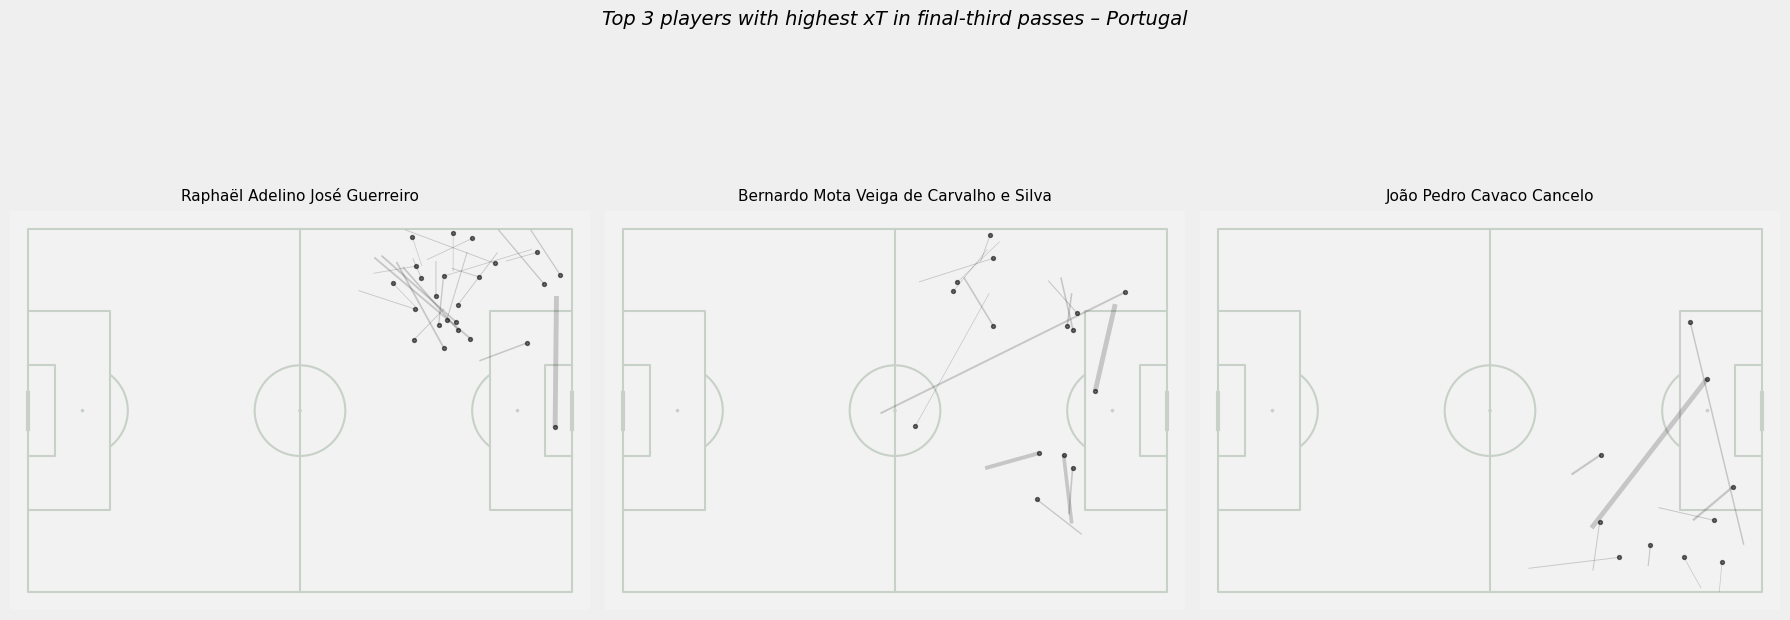

In [59]:
plot_top3_final_third_xT_players(passes_xT_df, "Portugal")

## Visualization

#### 1. Visualize only passes that significantly increased attacking threat

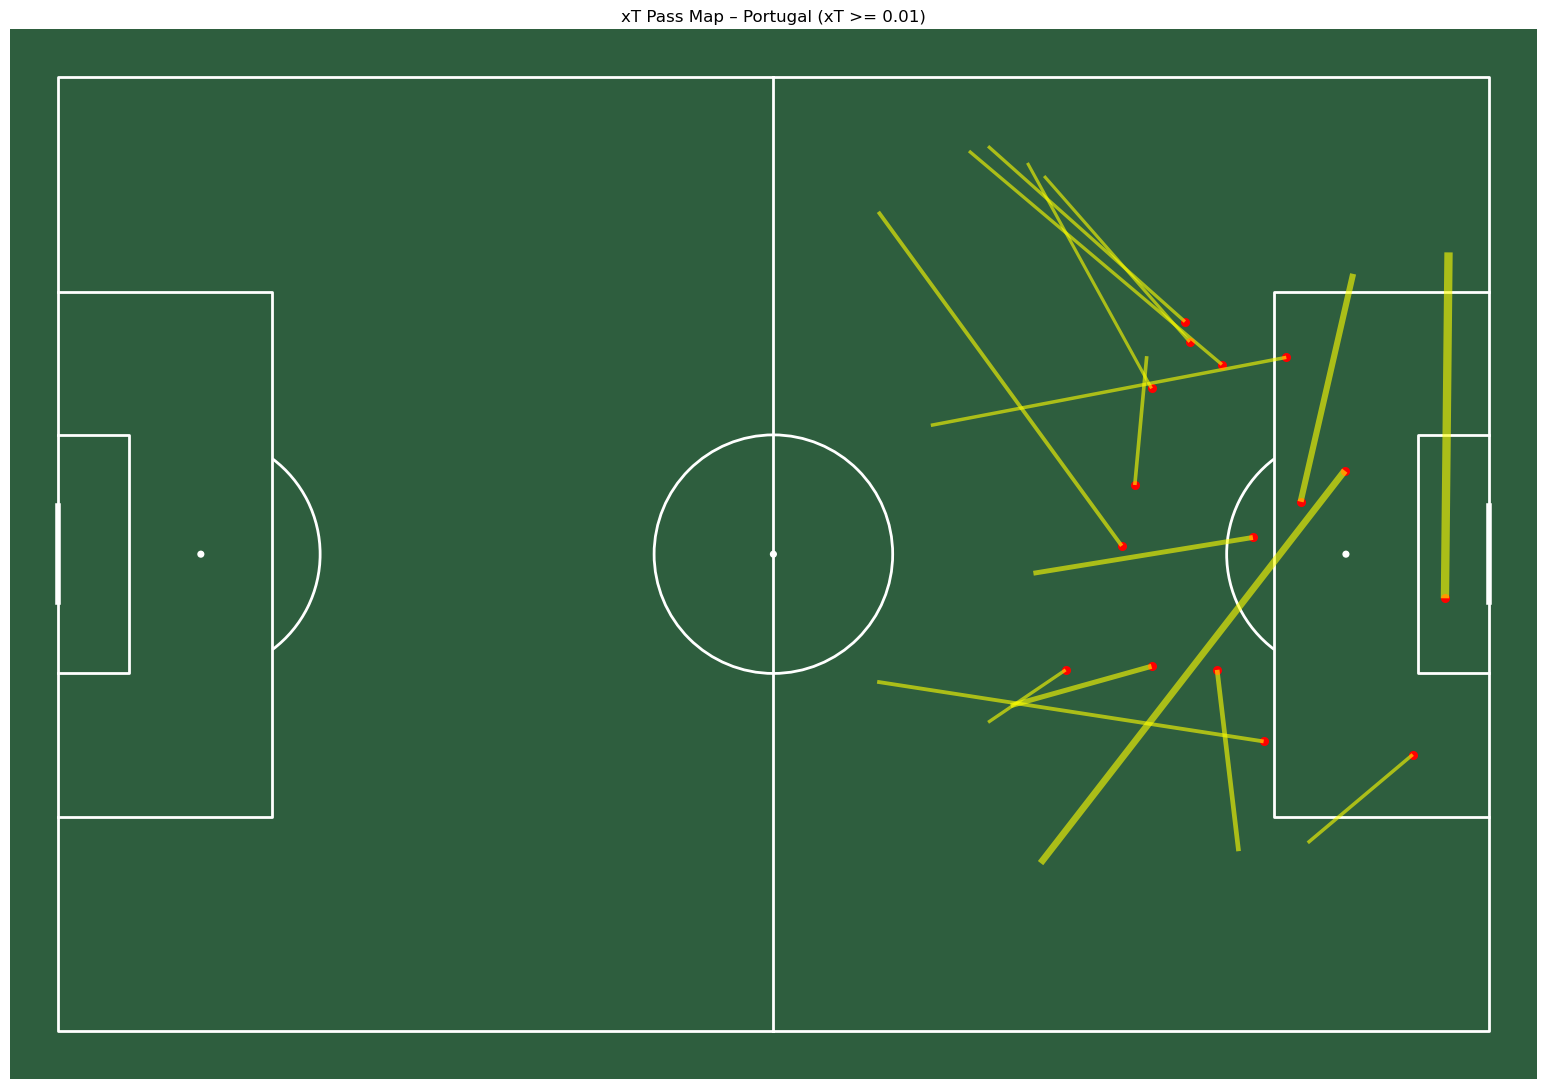

In [66]:
plot_xT_pass_map(passes_xT_df, "Portugal", min_xT=0.01)

## Visualization (Shots)

#### 2. Compare shot locations between both teams

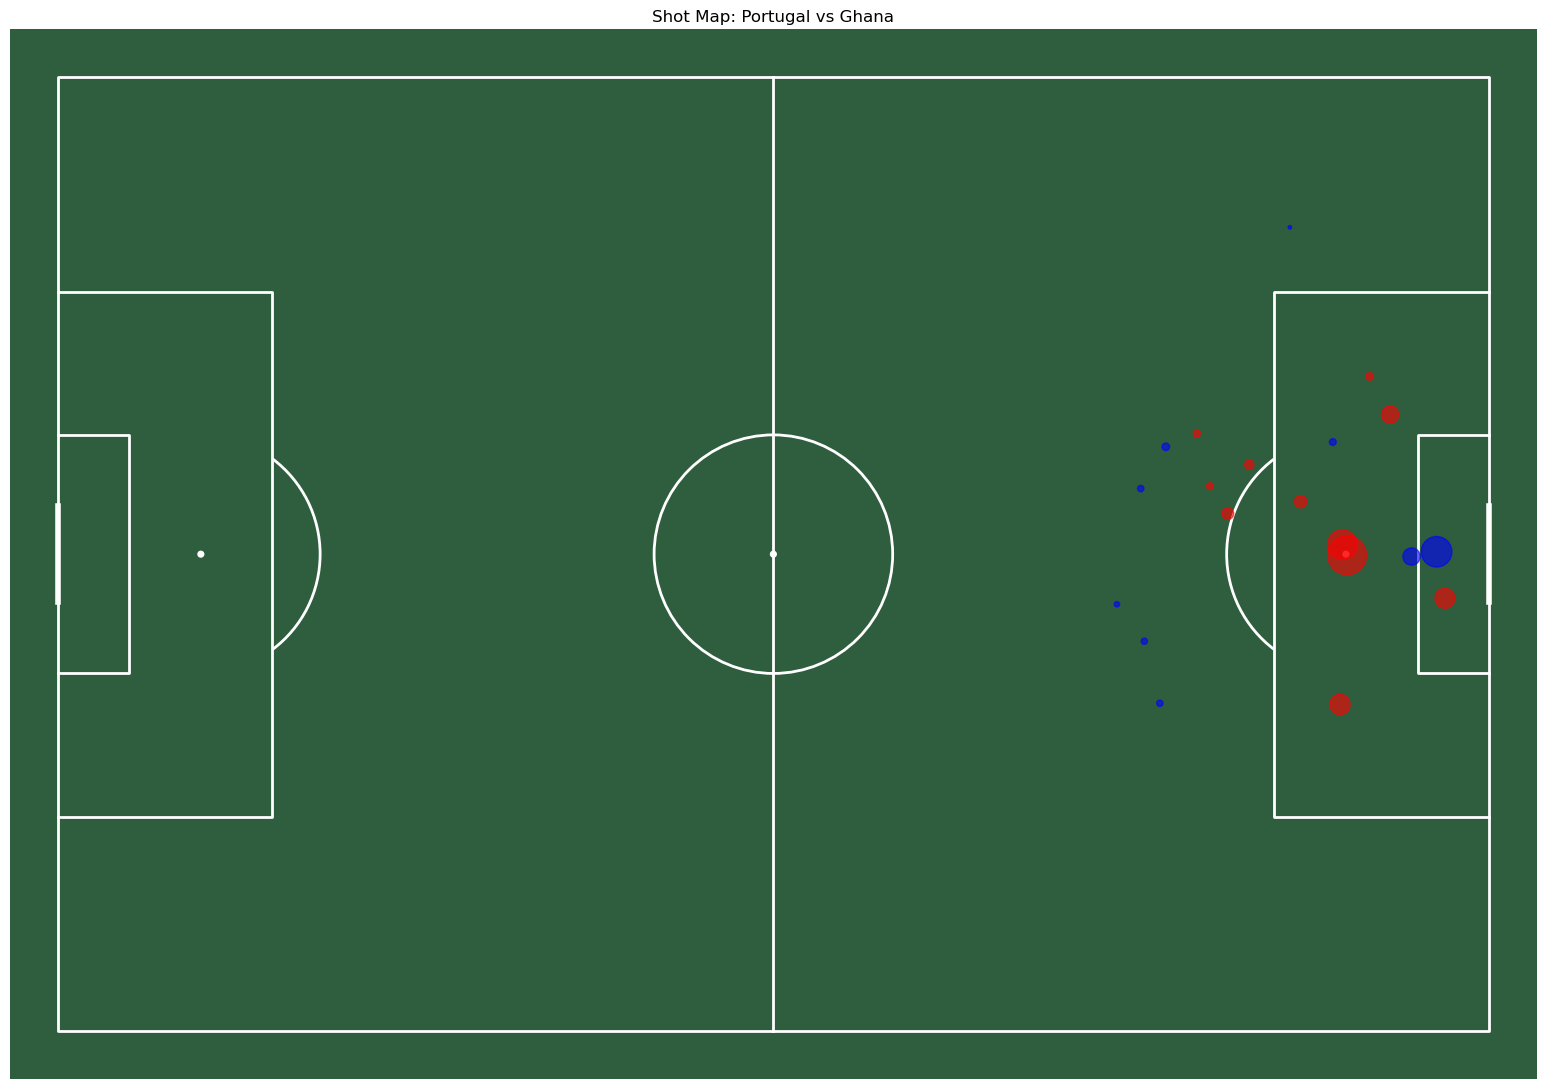

In [97]:
plot_shot_map_by_team(shots_df, team_name, opponent_name)

#### 3. Visualize goal locations only

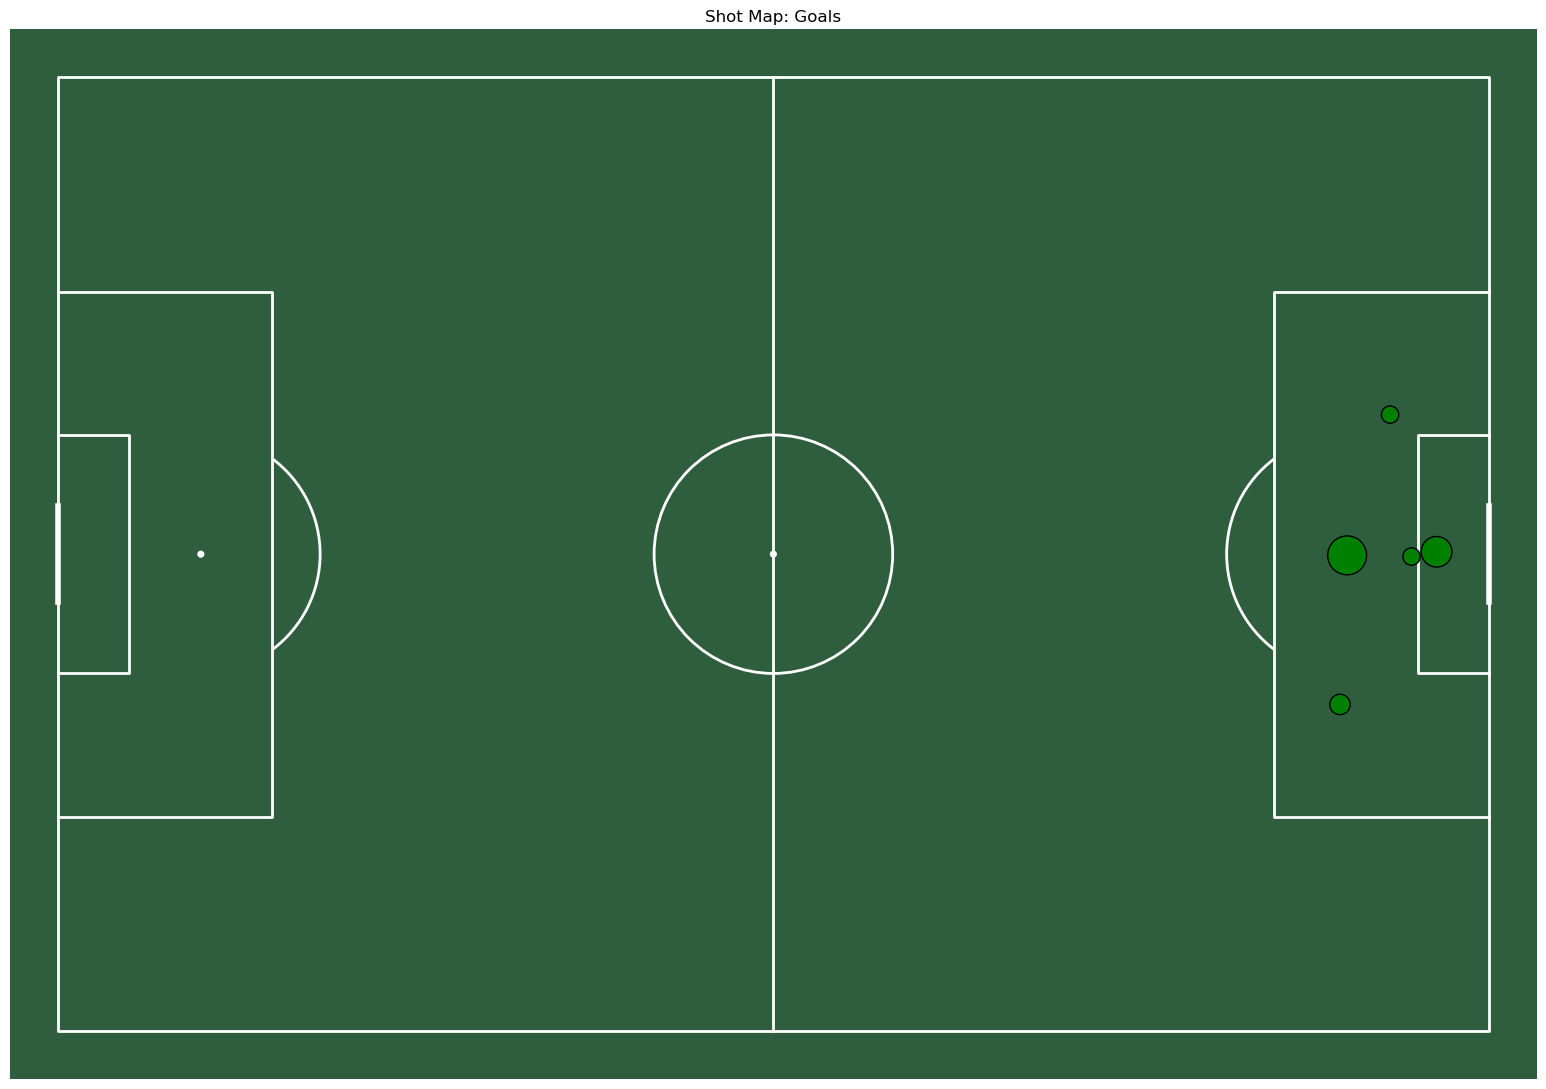

In [77]:
plot_goals_map(shots_df)

#### 4. Detailed shot map with player labels and xG sizing

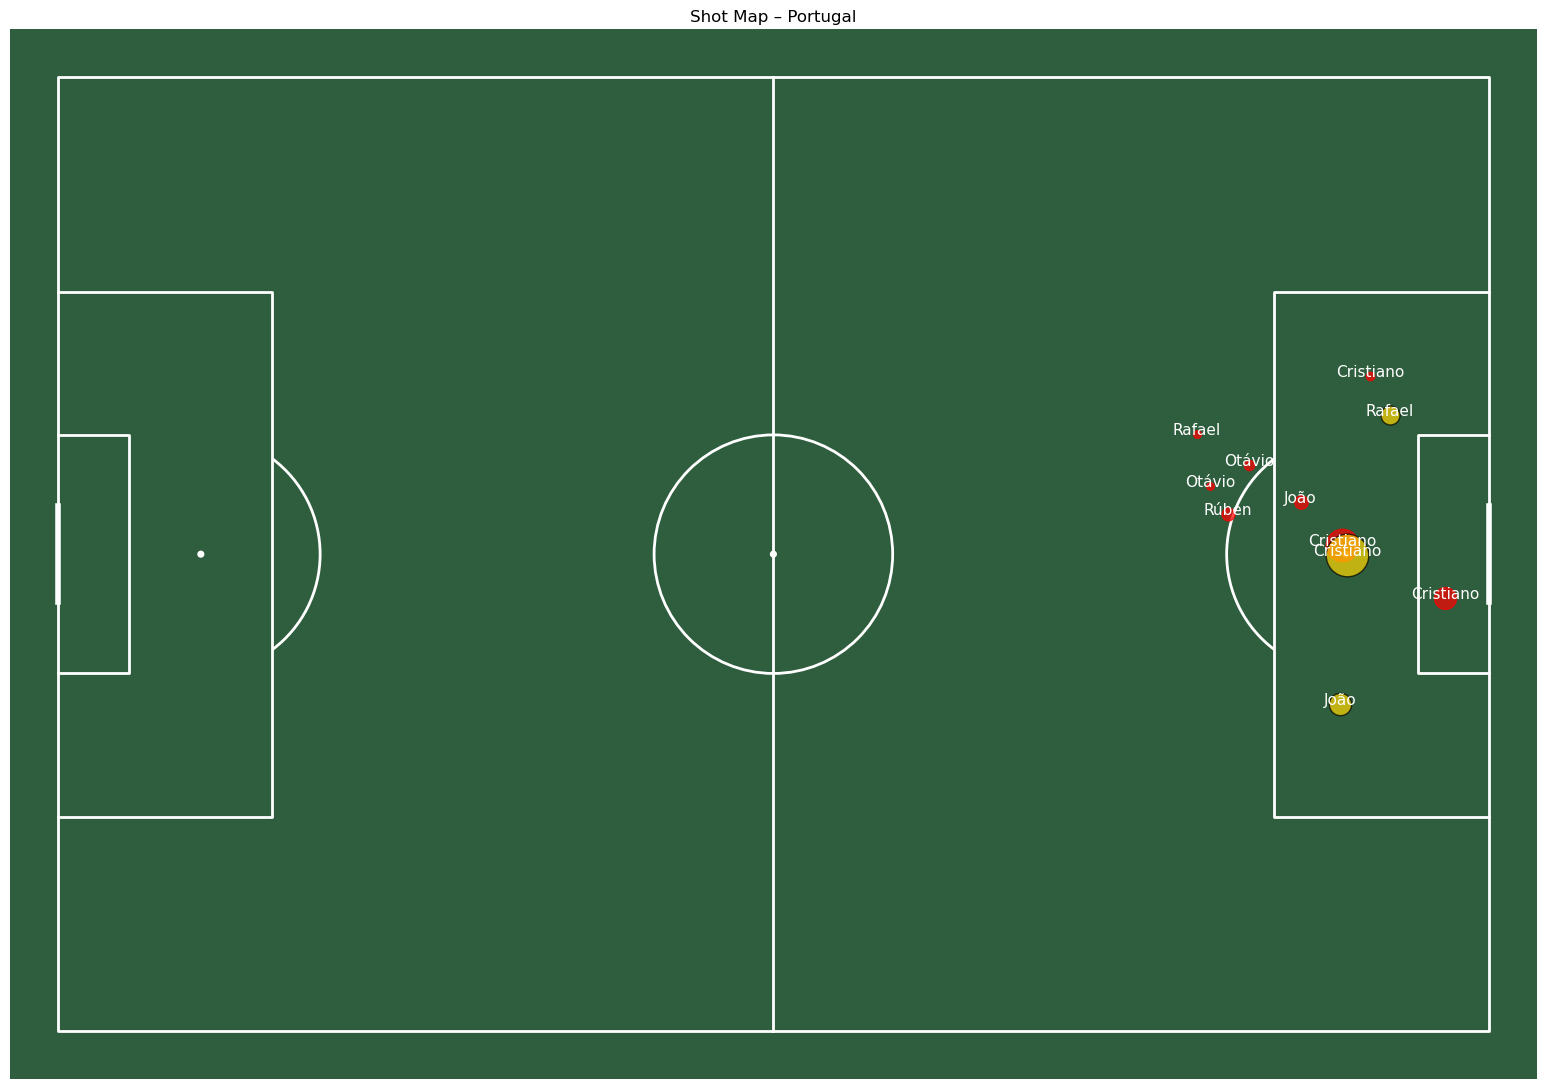

In [78]:
plot_shot_map_advanced(shots_df, team_name)

## Visualization Pass Network

#### 1. Structured passing network showing main connections

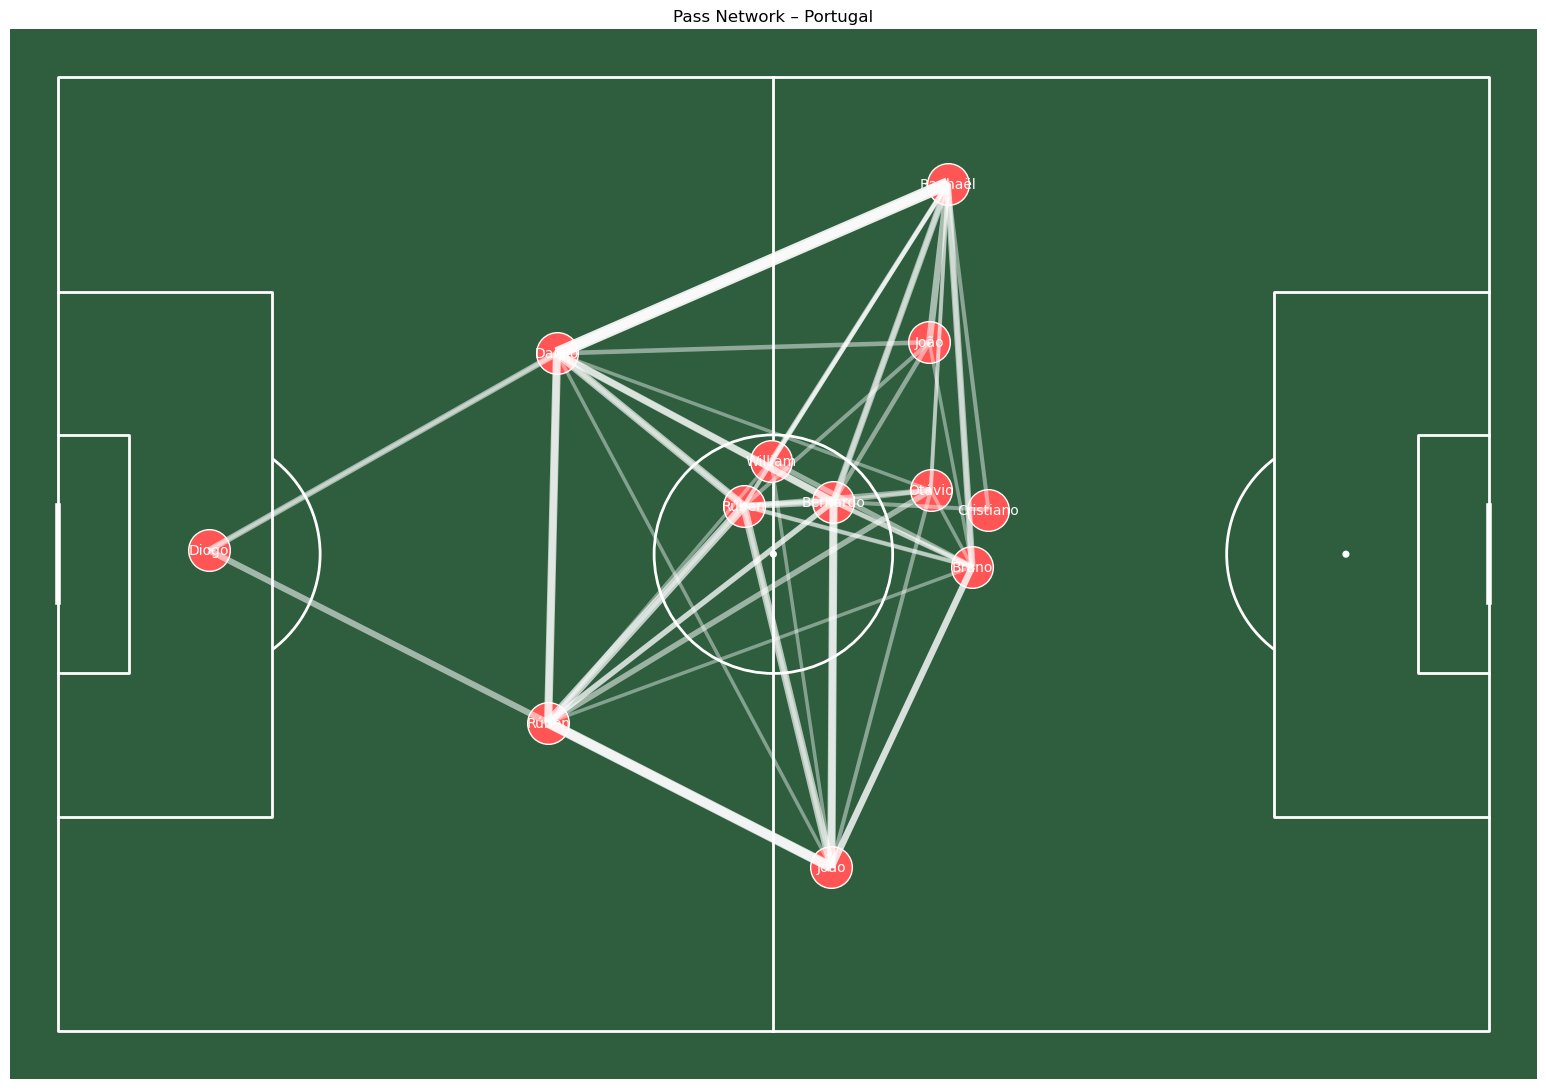

In [68]:
avg_positions, pass_links = compute_pass_network(passes_df, team_name)
plot_pass_network_advanced(avg_positions, pass_links, team_name)